In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections.abc import Mapping
from IPython.display import display
from plotting_utils import create_df_runs, apply_presentation_theme
from matplotlib.container import BarContainer
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

In [2]:
#df_runs = create_df_runs()
df_runs = create_df_runs(hypothesis_to_filter="indeterminacy_concat_cases_reruns")

df_runs created and its head looks like this:


,level_0,index,run_name,model,prompt,url_allowed,commit,hypothesis_name,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,44,44,2026-05-15T16:38:33.440343__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,c85e5338,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
1,53,54,2026-05-15T16:24:28.072343__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,c85e5338,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
2,57,58,2026-05-15T15:14:48.442070__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,c85e5338,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, Accuracy-ChildBenefit-indeterminacy-v3.md, False)",3


In [3]:
df_runs.columns

Index(['level_0', 'index', 'run_name', 'model', 'prompt', 'url_allowed',
       'commit', 'hypothesis_name', 'results', 'prompt_name', 'prompt_type',
       'model_name', 'config_key', 'prompt_version', 'config_label'],
      dtype='object')

In [4]:
def build_case_reliability_matrix(target_runs: pd.DataFrame) -> pd.DataFrame:
    """
    Build a pass/fail matrix for one configuration across multiple runs.

    Rows = case IDs
    Columns = run names
    Values = boolean pass/fail
    """
    records: dict[str, dict[str, bool]] = {}

    for row in target_runs.itertuples(index=False):
        run_name = row.run_name
        results = row.results

        if not isinstance(results, Mapping):
            continue

        for case_id, case_data in results.items():
            if case_id == "run_config":
                continue

            if case_id not in records:
                records[case_id] = {}

            records[case_id][run_name] = case_data.get("overall_is_correct", False)

    df_matrix = pd.DataFrame.from_dict(records, orient="index")

    df_matrix["Pass_Rate"] = df_matrix.mean(axis=1)

    df_matrix["Category"] = pd.cut(
        df_matrix["Pass_Rate"],
        bins=[-0.1, 0.0, 0.99, 1.0],
        labels=["Systematic Fail", "Flaky", "Always Passes"],
    )

    return df_matrix


def build_reliability_matrices_by_config(
    df_runs: pd.DataFrame,
    min_runs: int = 3,
) -> dict[str, pd.DataFrame]:
    """
    Build one reliability matrix per configuration, keeping only configurations
    with at least `min_runs` runs.
    """
    # Group by the clean config_label instead of the tuple
    config_counts = df_runs["config_label"].value_counts()
    eligible_config_labels = config_counts[config_counts >= min_runs].index.tolist()

    matrices = {}

    for config_label in eligible_config_labels:
        target_runs = df_runs.loc[df_runs["config_label"] == config_label]
        matrices[config_label] = build_case_reliability_matrix(target_runs)

    return matrices

In [15]:
reliability_matrices = build_reliability_matrices_by_config(df_runs, min_runs=3)

for config_key, df_matrix in reliability_matrices.items():
    print(f"\n=== Reliability Summary: {config_key} ===")
    display(df_matrix["Category"].value_counts().to_frame("Number of Cases"))

    hard_cases = df_matrix[df_matrix["Pass_Rate"] < 1.0].sort_values("Pass_Rate")
    if not hard_cases.empty:
        print("\n🚨 Flaky and Failing Cases:")
        display(hard_cases[["Pass_Rate", "Category"]].head(100))


=== Reliability Summary: claude-sonnet-4-5 | Combined indeterminacy cohort ===


,Number of Cases
Category,
Always Passes,94
Flaky,68
Systematic Fail,37



🚨 Flaky and Failing Cases:


,Pass_Rate,Category
APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_013,0.000000,Systematic Fail
RESPONSIBILITY_INDET_PRIORITY_UNKNOWN_RND_026,0.000000,Systematic Fail
INFORMAL_ARRANGEMENT_INDET_BASIC_RND_016,0.000000,Systematic Fail
CLAIMANT_DISPUTE_INDET_UNRESOLVED_RND_057,0.000000,Systematic Fail
APPRENTICESHIP_INDET_STATUS_UNKNOWN_RND_050,0.000000,Systematic Fail
...,...,...
COMBO_FAIL_CARE_AND_NOT_LIVING_WITH,0.666667,Flaky
APPRENTICESHIP_LOCATION_INDET_NORTHERN_IRELAND_RND_014,0.666667,Flaky
RND_SET_2_005,0.666667,Flaky
RND_SET_2_028,0.666667,Flaky


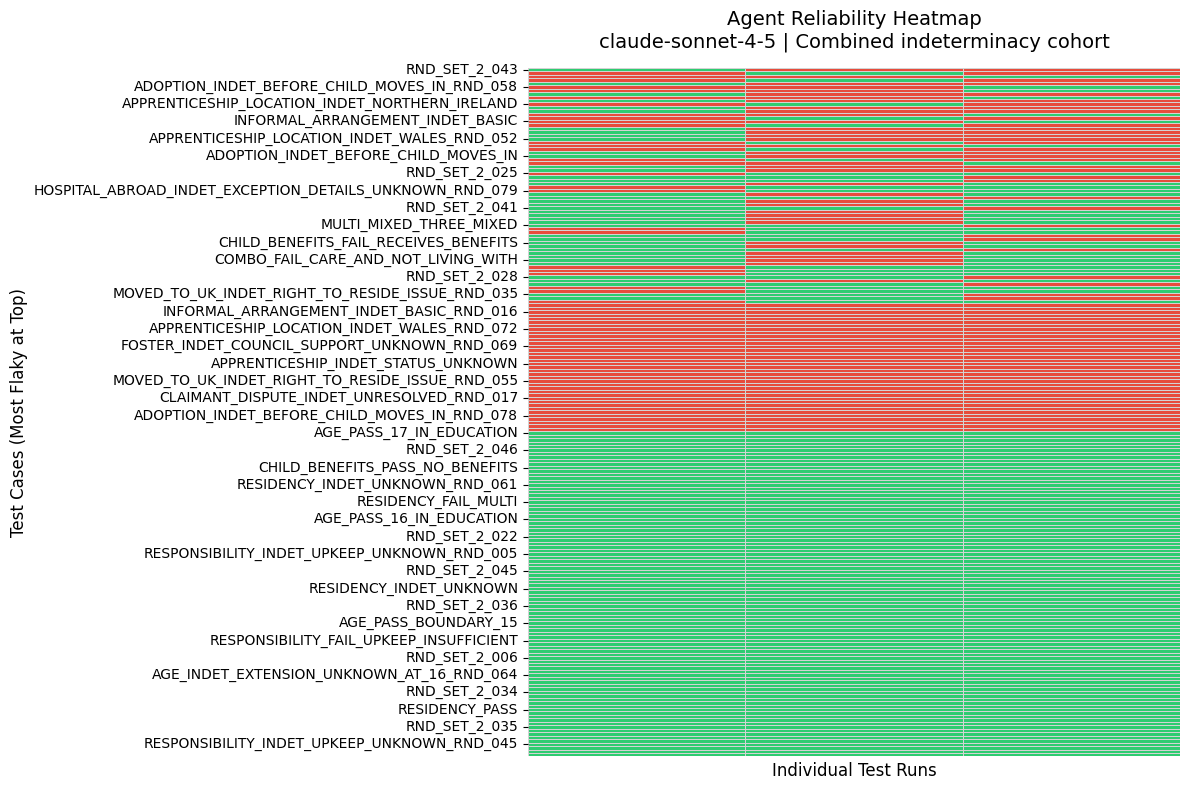

In [14]:
def plot_reliability_heatmaps(
    reliability_matrices: dict[str, pd.DataFrame],
) -> None:
    """
    Plot a reliability heatmap for each configuration.
    Sorted by variance (flakiness) so unreliable cases sit at the top.
    """
    cmap = sns.color_palette(["#e74c3c", "#2ecc71"])

    # Dictionary key is now just the string label
    for config_label, df_matrix in reliability_matrices.items():
        run_cols = [c for c in df_matrix.columns if c not in ["Pass_Rate", "Category"]]
        df_matrix["Flakiness"] = df_matrix[run_cols].var(axis=1)
        df_sorted = df_matrix.sort_values(
            by=["Flakiness", "Pass_Rate"], ascending=[False, True]
        )

        heatmap_data = df_sorted[run_cols].astype(float)

        if heatmap_data.empty:
            continue

        plt.figure(figsize=(12, 8))

        sns.heatmap(
            heatmap_data,
            cmap=cmap,
            cbar=False,
            linewidths=0.5,
            linecolor="lightgray",
            xticklabels=False,
        )

        # Use the config_label directly in the title
        plt.title(
            f"Agent Reliability Heatmap\n{config_label}",
            fontsize=14,
            pad=15,
        )

        plt.xlabel("Individual Test Runs", fontsize=12)
        plt.ylabel("Test Cases (Most Flaky at Top)", fontsize=12)

        plt.tight_layout()
        plt.show()


plot_reliability_heatmaps(reliability_matrices)

In [7]:
def plot_comparative_reliability(reliability_matrices: dict[str, pd.DataFrame]) -> None:
    """
    Creates a 100% stacked bar chart comparing the reliability
    and accuracy of different agent configurations.
    """
    records = []

    for config_label, df_matrix in reliability_matrices.items():
        # Calculate the percentage of cases in each category
        category_percentages = df_matrix["Category"].value_counts(normalize=True) * 100

        records.append(
            {
                "Configuration": config_label,  # Mapped directly!
                "Always Passes": category_percentages.get("Always Passes", 0),
                "Systematic Fail": category_percentages.get("Systematic Fail", 0),
                "Flaky (Non-Deterministic)": category_percentages.get("Flaky", 0),
            }
        )

    df_plot = pd.DataFrame(records).set_index("Configuration")

    # Sort the dataframe so the most reliable configs (lowest Flaky rate) are at the top
    df_plot = df_plot.sort_values(by="Flaky (Non-Deterministic)", ascending=True)

    # Plotting
    colors = ["#2ecc71", "#e74c3c", "#f1c40f"]  # Green, Red, Yellow

    ax = df_plot[
        ["Always Passes", "Systematic Fail", "Flaky (Non-Deterministic)"]
    ].plot(
        kind="barh",
        stacked=True,
        figsize=(12, max(4, len(df_plot) * 1.2)),
        color=colors,
        width=0.7,
    )

    plt.title("Configuration Comparison: Reliability vs. Accuracy", fontsize=16, pad=20)
    plt.xlabel("Percentage of Test Cases (%)", fontsize=12)
    plt.ylabel("")

    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    for container in ax.containers:
        for p in container:
            width = p.get_width()
            if width > 3:
                ax.annotate(
                    f"{width:.1f}%",
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=10,
                    fontweight="bold",
                )

    plt.tight_layout()
    plt.show()

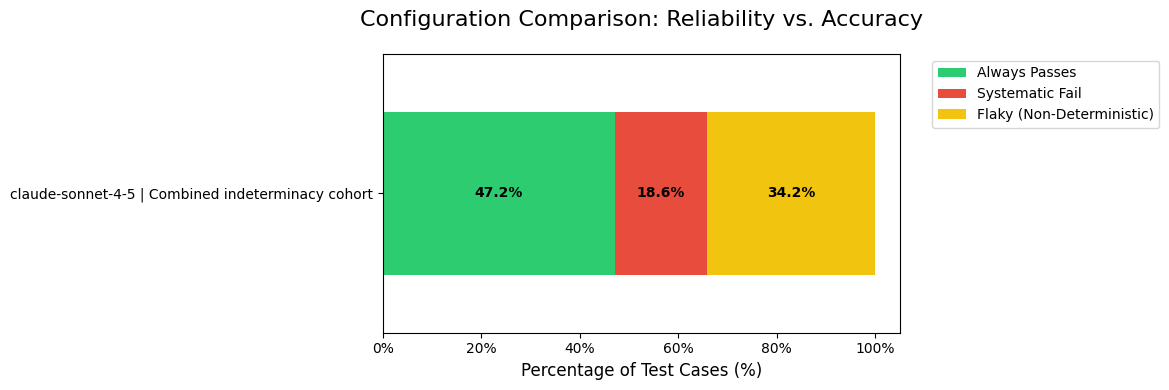

In [8]:
plot_comparative_reliability(reliability_matrices)

# Reliability breakdown by type

In [9]:
def wilson_ci(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """
    Wilson score interval for a binomial proportion.
    I thought this would be better than the default Seaborn
    CIs but it doesn't seem very different.

    Returns
    -------
    (lower, upper) as proportions on the 0-1 scale.
    """
    if n == 0:
        return 0.0, 0.0

    p = successes / n
    denom = 1 + (z**2 / n)
    centre = (p + z**2 / (2 * n)) / denom
    half_width = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2))) / denom
    lower = max(0.0, centre - half_width)
    upper = min(1.0, centre + half_width)
    return lower, upper


def plot_strict_reliability(
    reliability_matrices: dict[str, pd.DataFrame],
    subset: str | None = None,
    filename: str | None = None,
    aspect_ratio: float = 10.97 / 8.93,
    base_height: float = 6,
    presentation_theme: bool = False,
    confidence_level: float = 0.95,
    # Opus Training data only has 3 at time of finishing project so not fair
    # to compare reliability against those with 5 runs
    exclude: str | None = "claude-opus-4-5 | Training data only"
) -> None:
    """
    Plot a horizontal bar chart comparing the Strict Reliability Rate
    (proportion of cases that pass 100% of runs) across all configurations.

    Includes binomial confidence intervals using the Wilson method.
    """

    if confidence_level != 0.95:
        raise ValueError("This function currently supports only confidence_level=0.95.")

    reliability_matrices = {k : v for k, v in reliability_matrices.items() if k != exclude}
    records = []

    for config_label, df_matrix in reliability_matrices.items():
        n_cases = len(df_matrix)
        successes = (df_matrix["Category"] == "Always Passes").sum()
        rate_pct = (successes / n_cases) * 100 if n_cases > 0 else 0.0

        ci_low, ci_high = wilson_ci(successes, n_cases)
        ci_low_pct = ci_low * 100
        ci_high_pct = ci_high * 100

        records.append(
            {
                "Configuration": config_label,
                "Strict Reliability (%)": rate_pct,
                "n_cases": n_cases,
                "successes": successes,
                "ci_low": ci_low_pct,
                "ci_high": ci_high_pct,
            }
        )

    df_plot = pd.DataFrame(records)

    if subset:
        df_plot = df_plot[df_plot["Configuration"].str.contains(subset)]

    df_plot = df_plot.sort_values(
        by="Strict Reliability (%)", ascending=False
    ).reset_index(drop=True)

    width = base_height * aspect_ratio
    fig, ax = plt.subplots(figsize=(width, base_height))

    sns.barplot(
        data=df_plot,
        x="Strict Reliability (%)",
        y="Configuration",
        color="#2ecc71",
        edgecolor="black",
        linewidth=1,
        ax=ax,
    )

    # Add confidence interval bars
    y_positions = ax.get_yticks()
    x_values = df_plot["Strict Reliability (%)"].to_numpy()
    xerr_lower = x_values - df_plot["ci_low"].to_numpy()
    xerr_upper = df_plot["ci_high"].to_numpy() - x_values

    ax.errorbar(
        x=x_values,
        y=y_positions,
        xerr=[xerr_lower, xerr_upper],
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=4,
        zorder=10,
    )

    ax.set_title(
        "Strict Reliability Rate by Configuration\n"
        "(Proportion of Cases Passing 100% of Runs)",
        fontsize=14,
        pad=15,
    )
    ax.set_xlabel("Strict Reliability (%)", fontsize=12)
    ax.set_ylabel("")

    ax.set_xlim(0, 110)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

    for container in ax.containers:
        if isinstance(container, BarContainer):
            ax.bar_label(
                container,
                fmt="%.1f%%",
                padding=30,
                fontsize=11,
                #                fontweight="bold",
            )
    sns.despine()

    if presentation_theme:
        fig = apply_presentation_theme(fig)

    plt.tight_layout()

    if filename:
        outfile = f"figures/{filename}"
        fig.savefig(
            outfile,
            dpi=300,
            bbox_inches="tight",
            facecolor=fig.get_facecolor(),
        )
        print(f"File created: {outfile}")

    plt.show()

### All types

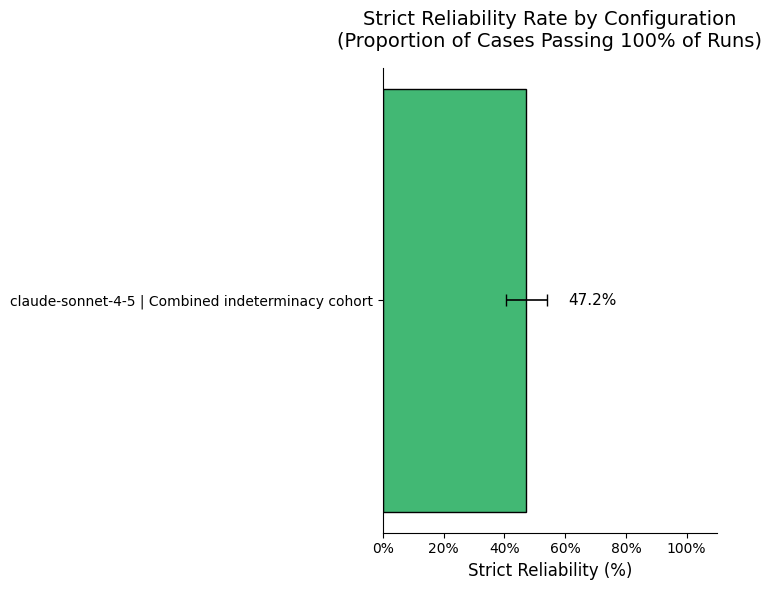

In [10]:
plot_strict_reliability(reliability_matrices, exclude="claude-opus-4-5 | Training data only")

### Rules in prompt

ValueError: 'x' and 'y' must have the same size

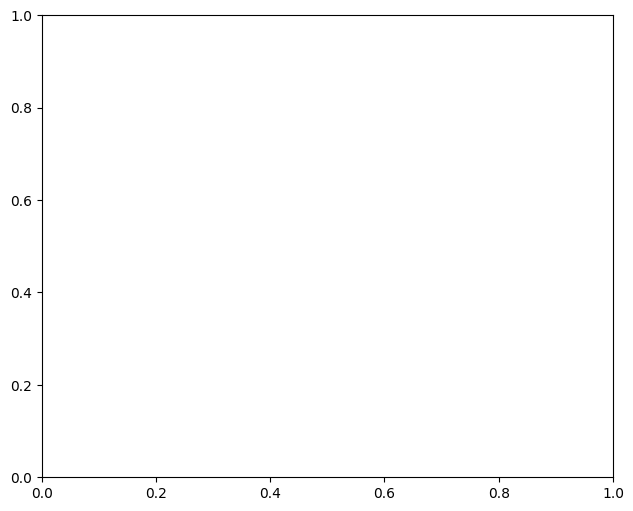

In [11]:
plot_strict_reliability(reliability_matrices, "Free text rules")

### Structured spec

In [ ]:
plot_strict_reliability(reliability_matrices, "Structured spec")

### Rules in URLs

In [ ]:
plot_strict_reliability(reliability_matrices, "Rules via URLs")

### Sonnet

In [ ]:
plot_strict_reliability(reliability_matrices, "sonnet", presentation_theme=True)

In [ ]:

def plot_cross_model_vulnerability(
    reliability_matrices: dict[str, pd.DataFrame], exclude_url_rules: bool = True
) -> None:
    """
    Plots a categorical heatmap showing only the test cases that failed
    at least once in ANY model configuration.
    Colors: Green (Always Passes), Orange (Systematic Fail), Red (Flaky/Unreliable).

    Args:
        reliability_matrices: Dictionary of reliability matrices.
        exclude_url_rules: If True, skips any configuration containing "Rules in URLs".
    """
    # 1. Combine Pass_Rates from all configs into a single DataFrame
    combined_data = {}
    for config_label, df_matrix in reliability_matrices.items():
        # Change 1: Filter out the high-variance "Rules in URLs" runs if requested
        if exclude_url_rules and "Rules in URLs" in config_label:
            continue

        for case_id, row in df_matrix.iterrows():
            if case_id not in combined_data:
                combined_data[case_id] = {}
            combined_data[case_id][config_label] = row["Pass_Rate"]

    df_combined = pd.DataFrame.from_dict(combined_data, orient="index")

    # Check if anything is left after filtering
    if df_combined.empty:
        print("No data available to plot after filtering.")
        return

    # 2. Filter for cases that failed at least once in ANY config
    # Keep rows where the minimum pass rate across all columns is less than 1.0
    df_filtered = df_combined[df_combined.min(axis=1) < 1.0].copy()

    if df_filtered.empty:
        print("No vulnerable cases found! All models passed 100%.")
        return

    # 3. Map pass rates to discrete integer categories for our custom colormap
    # 0 = Systematic Fail (Orange), 1 = Flaky (Red), 2 = Always Passes (Green)
    def categorize(rate):
        if pd.isna(rate):
            return np.nan
        if rate == 1.0:
            return 2
        if rate == 0.0:
            return 0
        return 1

    # Handle applymap deprecation for newer Pandas versions
    try:
        df_cat = df_filtered.map(categorize)
    except AttributeError:
        df_cat = df_filtered.applymap(categorize)

    # Sort rows so the "hardest/flakiest" cases (lowest scores) appear at the top
    df_cat["hardness_score"] = df_cat.sum(axis=1)
    df_cat = df_cat.sort_values("hardness_score", ascending=True).drop(
        columns=["hardness_score"]
    )

    # 4. Plotting Setup
    # Dynamically scale height based on how many vulnerable cases exist
    plt.figure(figsize=(10, max(5, len(df_cat) * 0.35)))

    # Custom Colormap matching your exact specifications
    my_cmap = ListedColormap(["#f39c12", "#e74c3c", "#2ecc71"])  # Orange, Red, Green

    ax = sns.heatmap(
        df_cat,
        cmap=my_cmap,
        cbar=False,
        linewidths=1,
        linecolor="white",
        vmin=0,
        vmax=2,
    )

    # Move X-axis labels to the top and rotate them so they are readable
    ax.xaxis.tick_top()
    plt.xticks(rotation=45, ha="left", fontsize=11)
    plt.yticks(fontsize=10)

    plt.ylabel("Vulnerable Test Cases", fontsize=12, labelpad=10)

    # Title (Pushed up to avoid colliding with top x-labels)
    plt.title(
        "Cross-Model Vulnerability Map\n(Isolating cases that failed at least once)",
        pad=40,
        fontsize=15,
        fontweight="bold",
    )

    # 5. Custom Legend (Change 2: Moved to the bottom)
    legend_elements = [
        Patch(facecolor="#2ecc71", edgecolor="black", label="Always Passes (100%)"),
        Patch(
            facecolor="#e74c3c", edgecolor="black", label="Flaky / Coin Toss (1% - 99%)"
        ),
        Patch(facecolor="#f39c12", edgecolor="black", label="Systematic Fail (0%)"),
    ]

    # ncol=3 spreads the legend out horizontally, bbox_to_anchor pulls it below the chart
    plt.legend(
        handles=legend_elements,
        bbox_to_anchor=(0.5, -0.05),
        loc="upper center",
        ncol=3,
        frameon=False,
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# Run the plot (Excludes "Rules in URLs" by default)
plot_cross_model_vulnerability(reliability_matrices, exclude_url_rules=True)